# Task 2: Trends and the spaghetti problem

This notebook examines life expectancy, regional trends, selected countries, and the income gap.


In [6]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

DATA = Path("data")
BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"
GREY, QUIET = "#b8b8b8", "#cfceca"
plt.rcParams.update({
    "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": "#e6e5e1", "axes.titleweight": "bold",
})

gapminder = pd.read_csv(DATA / "gapminder.csv")
life_by_continent = gapminder.groupby(["continent", "year"], as_index=False)["lifeExp"].mean()


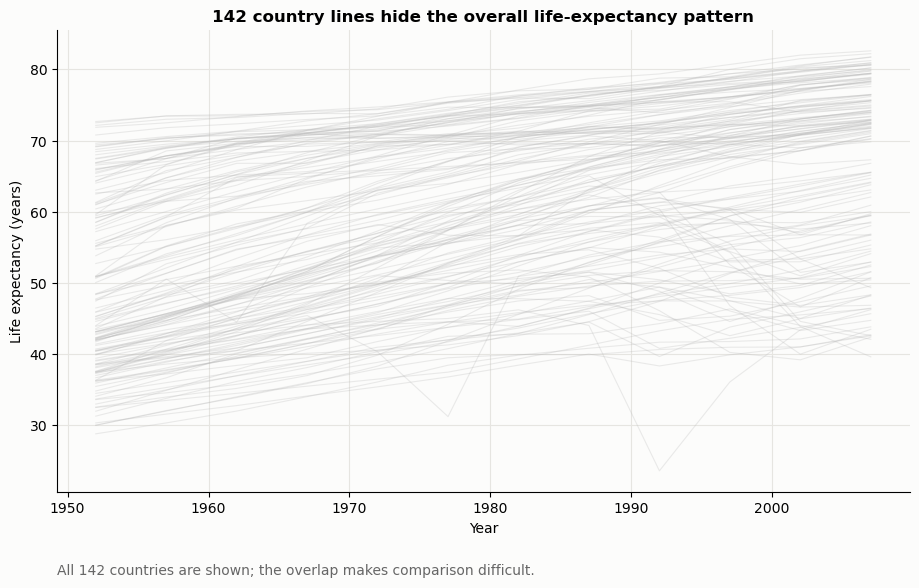

In [7]:
fig, ax = plt.subplots(figsize=(11, 6))
for country, group in gapminder.groupby("country"):
    ax.plot(group["year"], group["lifeExp"], color=GREY, alpha=0.28, linewidth=0.8)
ax.set_title("142 country lines hide the overall life-expectancy pattern")
ax.set_xlabel("Year"); ax.set_ylabel("Life expectancy (years)")
ax.text(0, -0.18, "All 142 countries are shown; the overlap makes comparison difficult.", transform=ax.transAxes, color="#666666")
plt.show()


### Why the first chart fails

There are too many nearly overlapping lines. A country legend would be unusable, and the reader cannot identify a general pattern reliably. This is an intentional anti-example.


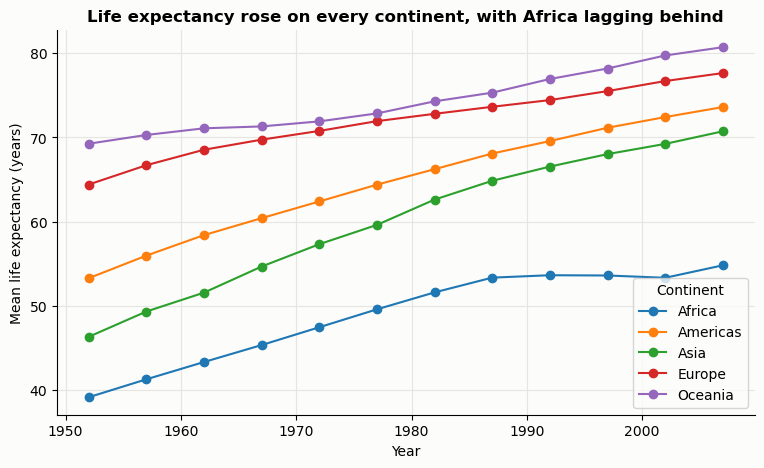

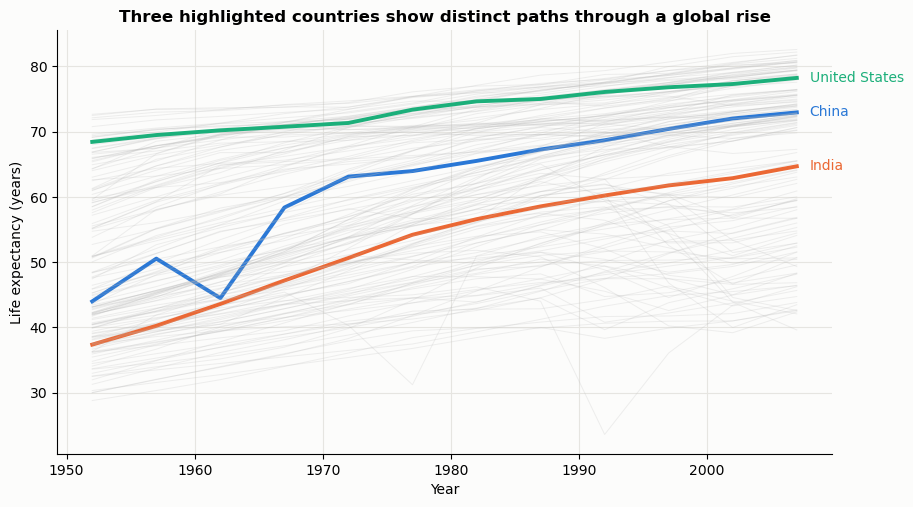

In [8]:
fig, ax = plt.subplots(figsize=(9, 5))
for continent, group in life_by_continent.groupby("continent"):
    ax.plot(group["year"], group["lifeExp"], marker="o", label=continent)
ax.set_title("Life expectancy rose on every continent, with Africa lagging behind")
ax.set_xlabel("Year"); ax.set_ylabel("Mean life expectancy (years)"); ax.legend(title="Continent")
plt.show()

selected = {"India": ORANGE, "China": BLUE, "United States": AQUA}
fig, ax = plt.subplots(figsize=(10, 5.5))
for country, group in gapminder.groupby("country"):
    ax.plot(group["year"], group["lifeExp"], color=GREY, alpha=0.22, linewidth=0.7)
    if country in selected:
        ax.plot(group["year"], group["lifeExp"], color=selected[country], linewidth=2.8)
        last = group.iloc[-1]
        ax.text(last["year"] + 1, last["lifeExp"], country, color=selected[country], va="center")
ax.set_title("Three highlighted countries show distinct paths through a global rise")
ax.set_xlabel("Year"); ax.set_ylabel("Life expectancy (years)")
plt.show()


### Aggregate versus highlight

The continent chart is best for broad regional comparison but hides country variation. The highlighted chart preserves the overall spread while directing attention to three specific trajectories. Aggregation answers a regional question; highlighting answers a selected-country question. Both charts use lines because year is ordered.


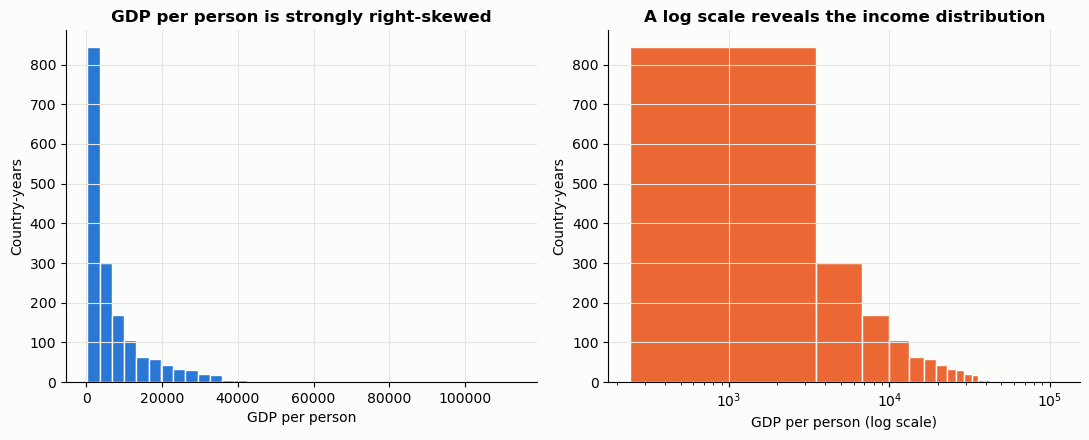

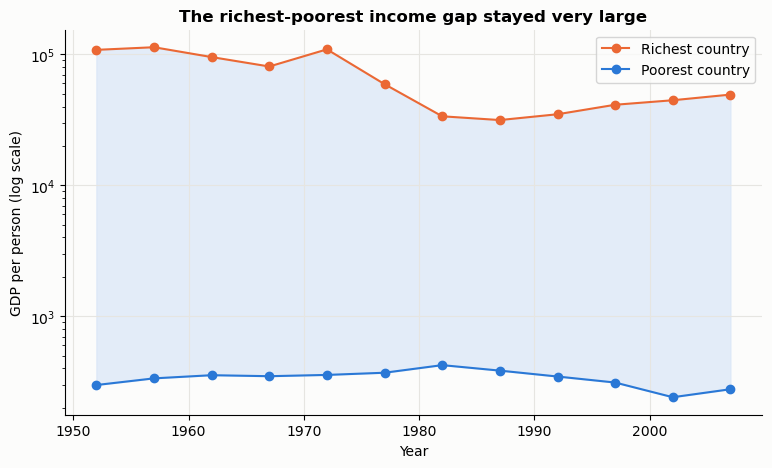

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].hist(gapminder["gdpPercap"], bins=35, color=BLUE, edgecolor="#fcfcfb")
axes[0].set_title("GDP per person is strongly right-skewed"); axes[0].set_xlabel("GDP per person"); axes[0].set_ylabel("Country-years")
axes[1].hist(gapminder["gdpPercap"], bins=35, color=ORANGE, edgecolor="#fcfcfb")
axes[1].set_xscale("log"); axes[1].set_title("A log scale reveals the income distribution"); axes[1].set_xlabel("GDP per person (log scale)"); axes[1].set_ylabel("Country-years")
fig.tight_layout(); plt.show()

country_income = gapminder.groupby(["country", "year"], as_index=False)["gdpPercap"].mean()
richest = country_income.loc[country_income.groupby("year")["gdpPercap"].idxmax()]
poorest = country_income.loc[country_income.groupby("year")["gdpPercap"].idxmin()]
gap = richest[["year", "gdpPercap"]].merge(poorest[["year", "gdpPercap"]], on="year", suffixes=("_richest", "_poorest"))
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(gap["year"], gap["gdpPercap_richest"], marker="o", color=ORANGE, label="Richest country")
ax.plot(gap["year"], gap["gdpPercap_poorest"], marker="o", color=BLUE, label="Poorest country")
ax.fill_between(gap["year"], gap["gdpPercap_poorest"], gap["gdpPercap_richest"], color="#d9e6f7", alpha=0.7)
ax.set_yscale("log"); ax.set_title("The richest-poorest income gap stayed very large")
ax.set_xlabel("Year"); ax.set_ylabel("GDP per person (log scale)"); ax.legend(); plt.show()


### Income conclusion

GDP per person is highly skewed, so the log-scale histogram is more useful for comparing ratios across countries. The richest-poorest chart shows that the gap remained very large and did not clearly narrow. The chart type is a line with a shaded interval because the question asks how the two extremes change over time.
